In [14]:
import torch
from torchvision import transforms
from PIL import Image
from CONFIG import *
from model import ResNet50_UNet
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [15]:
def remove_artifacts(mask):
    """
    Keeps only largest connected component
    mask: binary mask (0 or 255)
    """

    mask_bin = (mask > 0).astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

    if num_labels <= 1:
        return mask  # nothing to clean

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    cleaned_mask = (labels == largest_label).astype(np.uint8) * 255

    return cleaned_mask

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ktrhe/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 22.4MB/s]


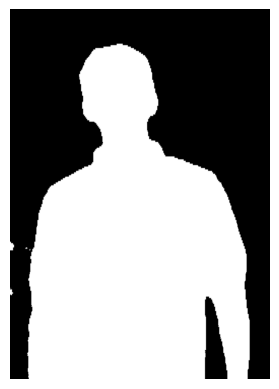

In [16]:
img_path = r"D:\personal\dandelli\Myphoto.png"

test_img = Image.open(img_path).convert('RGB')
size = test_img.size
test_img = test_img.resize((512, 512))
test_img_tensor = transforms.ToTensor()(test_img).unsqueeze(0).to(DEVICE)

model = ResNet50_UNet(in_ch=IN_CH, out_ch=OUT_CH, pretrained=False).to(DEVICE)
checkpoint = torch.load('models/resnet50_unet_20.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])


model.eval()
with torch.no_grad():
    pred_mask = model(test_img_tensor)
    pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()
    # pred_mask = pred_mask.squeeze().cpu().numpy()

pred_mask = (pred_mask > 0.5).astype('uint8') * 255
pred_mask = Image.fromarray(pred_mask).resize(size)
plt.imshow(pred_mask, cmap='gray')
plt.axis('off')
plt.show()

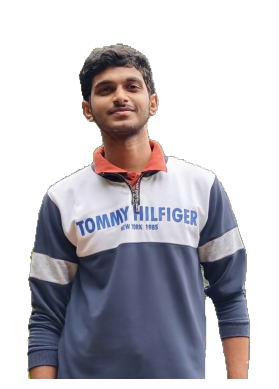

In [9]:
import numpy as np

with torch.no_grad():
    pred_mask = model(test_img_tensor)
    pred_mask = torch.sigmoid(pred_mask).squeeze().cpu().numpy()

# Ensure correct format
pred_mask = np.squeeze(pred_mask)
pred_mask = (pred_mask > 0.5).astype("uint8") * 255

# Remove small artifacts
pred_mask = remove_artifacts(pred_mask)

# Convert to PIL mask (use nearest to keep binary mask)
pred_mask_img = Image.fromarray(pred_mask, mode="L").resize(size, resample=Image.NEAREST)

# Open original image as RGBA
orig_img = Image.open(img_path).convert("RGBA")

# Create transparent result and paste original using mask
transparent_result = Image.new("RGBA", size, (0, 0, 0, 0))
transparent_result.paste(orig_img, (0, 0), mask=pred_mask_img)

# Save masked subject with transparency
out_path = "masked_subject_2.png"
transparent_result.save(out_path)

# Display the transparent result
plt.imshow(transparent_result)
plt.axis("off")
plt.show()